<a href="https://colab.research.google.com/github/syedshubha/PulseSCQ/blob/main/QuantumVerification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
%pip install --quiet qutip qutip-qip&> /dev/null

In [24]:
import qutip as qt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.linalg import polar

warnings.filterwarnings('ignore', category=FutureWarning)

In [25]:
# ============================================================
# Global configuration: gate + protocol parameters
# ============================================================

# Biased coin: V(λ) = R_y(2λ), here λ = π/4 → θ_gate = π/2
LAMBDA_COIN = np.pi / 4.0
THETA_GATE = 2.0 * LAMBDA_COIN
IDEAL_COIN_P1 = np.sin(LAMBDA_COIN) ** 2  # should be 0.5

# XOR classifier parameters are implicit in U_xor(x1, x2)

# Verification thresholds
EPS_D_PASS   = 0.02   # process infidelity threshold for PASS
EPS_LOG_PASS = 0.05   # coherent deviation threshold for PASS
EPS_INC_PASS = 0.05   # noise overhead threshold for PASS

D_HARD       = 0.30   # above this, consider hard fail
LOG_HARD     = 0.90   # ~almost orthogonal
INC_HARD     = 0.50   # large noise

# ============================================================
# Regimes: defining all cases here
# ============================================================

REGIMES = [
    {
        "name": "Calibrated",
        "params": {
            "J1Q": 0.0, "JQ2": 0.0,
            "A1": 0.0, "A2": 0.0, "Aro": 0.0,
            "delta1": 0.0, "delta2": 0.0, "delta_ro": 0.0
        }
    },
    {
        "name": "Moderate",
        "params": {
            "J1Q": 0.5, "JQ2": 0.5,         # high static coupling
            "A1": 0.0, "A2": 0.0, "Aro": 0.0,  # no drives
            "delta1": 10.0, "delta2": 10.0, "delta_ro": 0.0
        }
    },
    {
        "name": "Worst-case",
        "params": {
            "J1Q": 0.5, "JQ2": 0.5,           # high static coupling
            "A1": 0.5, "A2": 0.5, "Aro": 0.5, # max neighbor & readout drives
            "delta1": 10.0, "delta2": 10.0, "delta_ro": 0.0
        }
    }
]

In [26]:
# ============================================================
# Basic single-qubit unitaries
# ============================================================

I2 = qt.qeye(2)
X2 = qt.sigmax()
Y2 = qt.sigmay()
Z2 = qt.sigmaz()

PAULI_1Q = {
    "x": X2,
    "y": Y2,
    "z": Z2,
}

zero = qt.basis(2, 0)
one  = qt.basis(2, 1)
plus = (zero + one).unit()
minus = (zero - one).unit()
plus_i = (zero + 1j * one).unit()
minus_i = (zero - 1j * one).unit()

SHADOW_PROJECTORS_1Q = {
    "X": [plus.proj(), minus.proj()],
    "Y": [plus_i.proj(), minus_i.proj()],
    "Z": [zero.proj(), one.proj()],
}

T_MUB_STATES = [
    ("0", zero),
    ("1", one),
    ("+", plus),
    ("-", minus),
    ("+i", plus_i),
    ("-i", minus_i),
]

def Rx(theta):
    return qt.Qobj([[np.cos(theta/2), -1j*np.sin(theta/2)],
                    [-1j*np.sin(theta/2), np.cos(theta/2)]])

def Ry(theta):
    return qt.Qobj([[np.cos(theta/2), -np.sin(theta/2)],
                    [np.sin(theta/2),  np.cos(theta/2)]])

def Rz(theta):
    return qt.Qobj([[np.exp(-1j*theta/2), 0.0],
                    [0.0, np.exp(1j*theta/2)]])

U_cnot_mat = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ], dtype=complex)
U_cnot = qt.Qobj(U_cnot_mat, dims=[[2, 2], [2, 2]])
I = I2

In [27]:
# ============================================================
# Pulse shape and Hamiltonian simulation
# ============================================================

def pulse_shape(shape="cos", A=1.0, delta=0.0, sigma=0.1,
                alpha=0.5, chirp_rate=0.0, t_duration=1.0):
    t_center = t_duration / 2
    if shape == "cos":
        return lambda t, args: A * np.cos(delta * t)
    elif shape == "gaussian":
        return lambda t, args: A * np.exp(-((t - t_center)**2) / (2 * sigma**2))
    elif shape == "square":
        return lambda t, args: A if (t_center - 0.2*t_duration) <= t <= (t_center + 0.2*t_duration) else 0.0
    elif shape == "chirp":
        return lambda t, args: A * np.cos((delta + chirp_rate * t) * t)
    elif shape == "drag":
        return lambda t, args: A * (
            np.exp(-((t - t_center)**2)/(2 * sigma**2))
            - alpha * (t - t_center) / sigma**2 * np.exp(-((t - t_center)**2)/(2 * sigma**2))
        )
    else:
        raise ValueError(f"Unknown pulse shape: {shape}")

def get_final_state_for_qpt(qubit_Q_input_dm, theta_gate, rest_params):
    """
    Simulate H(t) = H_Q(t) + H_rest(t) for a specific 1-qubit input DM on Q.
    Neighbors q1 and q2 start in |0>.
    """
    I = qt.qeye(2)
    zero = qt.basis(2, 0)

    # Initial 3-qubit state: |0>_q1 ⊗ rho_Q ⊗ |0>_q2
    state_init_3q = qt.tensor(zero.proj(), qubit_Q_input_dm, zero.proj())

    t_duration = 1.0
    tlist = np.linspace(0, t_duration, 50)

    # 1. H_rest(t)
    H_couple_1Q = rest_params['J1Q'] * qt.tensor(qt.sigmay(), qt.sigmax(), I)
    H_couple_Q2 = rest_params['JQ2'] * qt.tensor(I, qt.sigmax(), qt.sigmay())
    H_static = H_couple_1Q + H_couple_Q2

    coeff1 = pulse_shape(shape="chirp",
                         A=rest_params['A1'],
                         delta=rest_params['delta1'],
                         chirp_rate=0.5,
                         t_duration=t_duration)
    coeff2 = pulse_shape(shape="chirp",
                         A=rest_params['A2'],
                         delta=rest_params['delta2'],
                         chirp_rate=0.5,
                         t_duration=t_duration)
    H_drive1 = [qt.tensor(qt.sigmax(), I, I), coeff1]
    H_drive2 = [qt.tensor(I, I, qt.sigmax()), coeff2]

    coeff_ro = pulse_shape(shape="cos",
                           A=rest_params['Aro'],
                           delta=rest_params['delta_ro'],
                           t_duration=t_duration)
    H_ro = [qt.tensor(I, qt.sigmax(), I), coeff_ro]

    # 2. H_Q(t): Gaussian drive on Q in Y
    sigma_gate = 0.2
    A_Q = (theta_gate / 2.0) / (sigma_gate * np.sqrt(2 * np.pi))
    coeff_Q = pulse_shape(shape="gaussian",
                          A=A_Q, sigma=sigma_gate,
                          t_duration=t_duration)
    H_gate_Q = [qt.tensor(I, qt.sigmay(), I), coeff_Q]

    # 3. Combine and simulate
    H_total = [H_static, H_drive1, H_drive2, H_ro, H_gate_Q]
    sol = qt.mesolve(H_total, state_init_3q, tlist, c_ops=[], e_ops=[])

    rho_final_total = sol.states[-1]
    rho_Q_final = rho_final_total.ptrace(1)  # trace out q1, q2
    return rho_Q_final

In [28]:
# ============================================================
# QPT and Choi reconstruction
# ============================================================

def perform_qpt_pipeline(theta_gate, rest_params):
    """
    Full single-qubit QPT on Q to reconstruct C_choi for E_phys.
    Returns C_choi as 4x4 Qobj.
    """
    psi_0 = qt.basis(2, 0)
    psi_1 = qt.basis(2, 1)
    psi_plus = (psi_0 + psi_1).unit()
    psi_plus_i = (psi_0 + 1j * psi_1).unit()

    rho_in_list = [
        psi_0.proj(),      # |0><0|
        psi_1.proj(),      # |1><1|
        psi_plus.proj(),   # |+><+|
        psi_plus_i.proj()  # |+i><+i|
    ]

    rho_out_list = []
    for rho_in in rho_in_list:
        rho_out = get_final_state_for_qpt(rho_in, theta_gate, rest_params)
        rho_out_list.append(rho_out)

    rho0_out, rho1_out, rho_plus_out, rho_plus_i_out = rho_out_list

    A_out = rho0_out
    B_out = rho1_out

    S = A_out + B_out
    X = 2 * rho_plus_out - S
    Y = 2 * rho_plus_i_out - S

    C_out = 0.5 * (X + 1j * Y)  # E(|0><1|)
    D_out = 0.5 * (X - 1j * Y)  # E(|1><0|)

    zero = qt.basis(2, 0)
    one  = qt.basis(2, 1)

    proj00 = zero * zero.dag()
    proj11 = one * one.dag()
    proj01 = zero * one.dag()
    proj10 = one * zero.dag()

    C_choi = (
        qt.tensor(proj00, A_out) +
        qt.tensor(proj01, C_out) +
        qt.tensor(proj10, D_out) +
        qt.tensor(proj11, B_out)
    )
    return C_choi

def kraus_operators_from_choi(C_choi, tol=1e-8):
    """
    Extract Kraus operators from a Choi matrix C (4x4 Qobj).
    Includes a normalization step to enforce trace preservation.
    """
    C_mat = C_choi.full()
    eigvals, eigvecs = np.linalg.eigh(C_mat)

    d = 2
    kraus_ops_raw = []
    for k in range(len(eigvals)):
        lam = eigvals[k]
        if np.real(lam) > tol:
            v = eigvecs[:, k]
            K_mat = np.sqrt(lam) * v.reshape((d, d), order='F')
            kraus_ops_raw.append(qt.Qobj(K_mat))

    if not kraus_ops_raw:
        return [qt.Qobj(np.zeros((2, 2), dtype=complex))]

    sum_ops = sum([K.dag() * K for K in kraus_ops_raw])
    trace_val = np.real(sum_ops.tr()) / d
    if trace_val <= 0:
        norm_factor = 1.0
    else:
        norm_factor = 1.0 / np.sqrt(trace_val)

    kraus_ops_normalized = [K * norm_factor for K in kraus_ops_raw]
    return kraus_ops_normalized

def choi_from_kraus(kraus_ops):
    """
    Given Kraus operators {K_i} for a 1-qubit channel, build its Choi matrix:
        C = sum_i vec(K_i) vec(K_i)^\dagger
    using column-stacking (Fortran order) vectorization.
    """
    d = kraus_ops[0].shape[0]  # d = 2
    C = np.zeros((d*d, d*d), dtype=complex)
    for K in kraus_ops:
        Kmat = K.full()
        v = Kmat.reshape(d*d, order='F')  # column vectorization
        C += np.outer(v, v.conj())
    return qt.Qobj(C)

<>:88: SyntaxWarning: invalid escape sequence '\d'
<>:88: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2848/1407188518.py:88: SyntaxWarning: invalid escape sequence '\d'
  C = sum_i vec(K_i) vec(K_i)^\dagger


In [29]:
# ============================================================
# Isometry fit: E_phys ≈ N ∘ U_eff
# ============================================================

def su2_axis_angle(U_qobj, tol=1e-10):
    """
    Given a 2x2 unitary Qobj, return (theta, n_axis, U_su2)
    with det(U_su2) = 1 and U_su2 = exp(-i * theta/2 * n·σ).
    """
    U = U_qobj.full()
    detU = np.linalg.det(U)
    phi = np.angle(detU) / 2.0
    U_su2 = U * np.exp(-1j * phi)

    trU = np.trace(U_su2)
    cos_half_theta = np.real(trU) / 2.0
    cos_half_theta = np.clip(cos_half_theta, -1.0, 1.0)
    theta = 2.0 * np.arccos(cos_half_theta)

    if abs(theta) < tol:
        return 0.0, np.array([0.0, 0.0, 1.0]), qt.Qobj(U_su2)

    sigmas = [qt.sigmax(), qt.sigmay(), qt.sigmaz()]
    n = []
    for sigma in sigmas:
        val = np.trace(sigma.full().conj().T @ U_su2)
        n_k = (1j * val) / (2.0 * np.sin(theta / 2.0))
        n.append(np.real(n_k))

    n = np.array(n)
    n_norm = np.linalg.norm(n)
    if n_norm > tol:
        n = n / n_norm
    else:
        n = np.array([0.0, 0.0, 1.0])

    return float(theta), n, qt.Qobj(U_su2)

def fit_unitary_plus_noise_from_choi(C_choi, tol=1e-8):
    """
    Given a Choi matrix C_choi (4x4 Qobj) for a 1-qubit channel E_phys,
    factor E_phys ≈ N ∘ U_eff where:

      - U_eff is a 1-qubit unitary (dominant coherent part)
      - N is a Pauli-like noise channel with Kraus operators L_i.
    """
    # 1. Get TP Kraus operators K_i of E_phys
    kraus_ops = kraus_operators_from_choi(C_choi, tol=tol)

    # 2. Pick dominant Kraus by Frobenius norm
    fro_norms = [np.linalg.norm(K.full(), 'fro') for K in kraus_ops]
    k0_index = int(np.argmax(fro_norms))
    K0 = kraus_ops[k0_index]

    # Optional: singular values of K0 to check "mostly unitary"
    svals = np.linalg.svd(K0.full(), compute_uv=False)
    dominant_sv = float(np.max(svals))

    # 3. Polar decomposition: K0 = U_eff · H  (U_eff unitary)
    from scipy.linalg import polar
    U_eff_mat, H = polar(K0.full())
    U_eff = qt.Qobj(U_eff_mat)

    # 4. Extract axis-angle for U_eff (for reporting)
    theta_eff, n_axis, U_su2 = su2_axis_angle(U_eff)

    # 5. Define noise channel N via L_i = K_i · U_eff.dag()
    L_ops = [K * U_eff.dag() for K in kraus_ops]

    # 6. Compute Pauli-transfer diagonal for N (approximate Pauli channel)
    paulis = [qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()]
    lambdas = []

    for j in range(1, 4):  # X, Y, Z
        sigma_j = paulis[j]
        N_sigma_j = sum([L * sigma_j * L.dag() for L in L_ops])
        lam_j = 0.5 * np.trace(sigma_j.full().conj().T @ N_sigma_j.full()).real
        lambdas.append(lam_j)

    lam_x, lam_y, lam_z = lambdas

    # 7. Map lambdas to Pauli probabilities (Pauli channel approximation)
    p_I = (1 + lam_x + lam_y + lam_z) / 4.0
    p_X = (1 + lam_x - lam_y - lam_z) / 4.0
    p_Y = (1 - lam_x + lam_y - lam_z) / 4.0
    p_Z = (1 - lam_x - lam_y + lam_z) / 4.0

    ps = np.array([p_I, p_X, p_Y, p_Z])
    ps = np.clip(ps, 0.0, 1.0)
    if ps.sum() > 0:
        ps = ps / ps.sum()

    sum_L = sum([L.dag() * L for L in L_ops])

    return {
        "U_eff": U_eff,
        "theta_eff": float(theta_eff),
        "n_axis": n_axis,
        "dominant_singular_value": dominant_sv,
        "pauli_lambdas": (lam_x, lam_y, lam_z),
        "pauli_probs": ps,
        "kraus_noise": L_ops,
        "K0_index": k0_index,
        "sum_L_dag_L": sum_L
    }

In [30]:
# ============================================================
# Ideal channel for Ry(θ) and verification metrics
# ============================================================

def ideal_choi_ry(theta):
    U = Ry(theta)

    zero = qt.basis(2, 0)
    one  = qt.basis(2, 1)
    proj00 = zero * zero.dag()
    proj11 = one * one.dag()
    proj01 = zero * one.dag()
    proj10 = one * zero.dag()

    def E(rho):
        return U * rho * U.dag()

    A_out = E(proj00)
    B_out = E(proj11)
    C_out = E(proj01)
    D_out = E(proj10)

    C_choi = (
        qt.tensor(proj00, A_out) +
        qt.tensor(proj01, C_out) +
        qt.tensor(proj10, D_out) +
        qt.tensor(proj11, B_out)
    )
    return C_choi

def process_distance_D(C_ideal, C_phys):
    d = 2
    C_i = C_ideal.full()
    C_p = C_phys.full()
    F_proc = (1.0 / d**2) * np.trace(C_i.conj().T @ C_p)
    return float(1.0 - np.real(F_proc))

def delta_log(U_ideal, U_eff):
    M = U_ideal.dag() * U_eff
    val = M.tr()
    return float(np.sqrt(max(0.0, 1.0 - (abs(val)**2) / 4.0)))

def delta_inc(pauli_probs):
    p_I = pauli_probs[0]
    return float(1.0 - p_I)

In [31]:
# ============================================================
# Applying a channel from its Choi matrix
# ============================================================

def apply_channel_from_choi(C_choi, rho_in):
    """
    Apply the 1-qubit channel whose Choi matrix was built as in perform_qpt_pipeline:
        C = |0><0| ⊗ A_out + |0><1| ⊗ C_out
          + |1><0| ⊗ D_out + |1><1| ⊗ B_out.
    Then for ρ = [[ρ00, ρ01], [ρ10, ρ11]]:
        E(ρ) = ρ00 A_out + ρ01 C_out + ρ10 D_out + ρ11 B_out.
    """
    M = C_choi.full()

    # Block structure: [[A_out, C_out],
    #                   [D_out, B_out]]
    A_out = qt.Qobj(M[0:2, 0:2])
    C_out = qt.Qobj(M[0:2, 2:4])
    D_out = qt.Qobj(M[2:4, 0:2])
    B_out = qt.Qobj(M[2:4, 2:4])

    rm = rho_in.full()
    r00 = rm[0, 0]
    r01 = rm[0, 1]
    r10 = rm[1, 0]
    r11 = rm[1, 1]

    rho_out = (
        r00 * A_out +
        r01 * C_out +
        r10 * D_out +
        r11 * B_out
    )
    return rho_out

In [32]:
# ============================================================
# Protocol-level metrics: coin and XOR
# ============================================================

def biased_coin_prob_from_channel(C_choi, lam):
    """
    Given a *noise* channel C_choi and a bias λ, compute
    P(|1>) after ideal biased-coin state + noise.
    Ideal coin state: |ψ> = cos λ |0> + sin λ |1>.
    """
    psi0 = qt.basis(2, 0)
    psi1 = qt.basis(2, 1)

    psi_ideal = np.cos(lam) * psi0 + np.sin(lam) * psi1
    rho_ideal = psi_ideal * psi_ideal.dag()

    rho_out = apply_channel_from_choi(C_choi, rho_ideal)
    proj1 = psi1 * psi1.dag()
    return float((proj1 * rho_out).tr().real)


def coin_p1_from_channel(C_choi):
    zero = qt.basis(2, 0)
    one = qt.basis(2, 1)
    proj0 = zero * zero.dag()
    proj1 = one * one.dag()

    rho_out = apply_channel_from_choi(C_choi, proj0)
    p1 = (proj1 * rho_out).tr().real
    return float(p1)

def U_xor(x1, x2):
    """
    U_XOR(x1,x2) = Rx((2x2 - 1)π/2) Rz((2x1 - 1)π/2) H
    """
    ang_z = (2 * x1 - 1) * np.pi / 2.0
    ang_x = (2 * x2 - 1) * np.pi / 2.0
    H = qt.Qobj([[1, 1], [1, -1]]) / np.sqrt(2)
    return Rx(ang_x) * Rz(ang_z) * H

def xor_accuracy_from_channel(C_choi):
    zero = qt.basis(2, 0)
    proj0 = zero * zero.dag()

    accs = []
    for x1 in [0, 1]:
        for x2 in [0, 1]:
            U = U_xor(x1, x2)
            rho_in = proj0
            rho_after_U = U * rho_in * U.dag()
            rho_after_noise = apply_channel_from_choi(C_choi, rho_after_U)

            y = x1 ^ x2
            proj_y = qt.basis(2, y) * qt.basis(2, y).dag()
            p_correct = (proj_y * rho_after_noise).tr().real
            accs.append(p_correct)

    return float(np.mean(accs))

In [33]:
# ============================================================
# Verdict classification
# ============================================================

def classify_verdict(D_val, dlog, dinc):
    if (D_val <= EPS_D_PASS and
        dlog <= EPS_LOG_PASS and
        dinc <= EPS_INC_PASS):
        return "PASS"
    if (D_val >= D_HARD or
        dlog >= LOG_HARD or
        dinc >= INC_HARD):
        return "HARD FAIL"
    return "SOFT FAIL"

# ============================================================
# Main analysis for each regime
# ============================================================

def analyze_regime(regime_name, rest_params, theta_gate):
    # 1. Channel reconstruction: full physical channel E_phys
    C_phys = perform_qpt_pipeline(theta_gate, rest_params)
    C_ideal = ideal_choi_ry(theta_gate)

    # 2. Channel-level metrics from E_phys
    D_val  = process_distance_D(C_ideal, C_phys)
    fit_res = fit_unitary_plus_noise_from_choi(C_phys)

    U_eff       = fit_res["U_eff"]
    pauli_probs = fit_res["pauli_probs"]
    L_ops       = fit_res["kraus_noise"]   # Kraus operators for N

    U_ideal = Ry(theta_gate)
    dlog = delta_log(U_ideal, U_eff)
    dinc = delta_inc(pauli_probs)

    verdict = classify_verdict(D_val, dlog, dinc)

    # 3. Build Choi for the **noise channel** N from {L_i}
    C_noise = choi_from_kraus(L_ops)

    # 4. Protocol-level metrics: apply N after ideal circuits
    coin_p = biased_coin_prob_from_channel(C_noise, LAMBDA_COIN)
    xor_acc = xor_accuracy_from_channel(C_noise)

    return {
        "name": regime_name,
        "params": rest_params,
        "D": D_val,
        "delta_log": dlog,
        "delta_inc": dinc,
        "verdict": verdict,
        "coin_p1": coin_p,
        "xor_acc": xor_acc
    }

In [34]:
# ============================================================
# Running all regimes and printing a compact summary
# ============================================================

if __name__ == "__main__":
    header = (
        "Regime, "
        "J1Q, JQ2, A1, A2, Aro, delta1, delta2, delta_ro, "
        "D, δ_log, δ_inc, "
        "P_coin(|1>), XOR_acc, Verdict"
    )
    print(header)

    for reg in REGIMES:
        name = reg["name"]
        params = reg["params"]
        res = analyze_regime(name, params, THETA_GATE)

        p = res["params"]
        line = (
            f"{res['name']}, "
            f"{p['J1Q']:.3f}, {p['JQ2']:.3f}, "
            f"{p['A1']:.3f}, {p['A2']:.3f}, {p['Aro']:.3f}, "
            f"{p['delta1']:.3f}, {p['delta2']:.3f}, {p['delta_ro']:.3f}, "
            f"{res['D']:.4f}, {res['delta_log']:.4f}, {res['delta_inc']:.4f}, "
            f"{res['coin_p1']:.4f}, {res['xor_acc']:.4f}, {res['verdict']}"
        )
        print(line)

Regime, J1Q, JQ2, A1, A2, Aro, delta1, delta2, delta_ro, D, δ_log, δ_inc, P_coin(|1>), XOR_acc, Verdict
Calibrated, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.0001, 0.0098, 0.0000, 0.5000, 1.0000, PASS
Moderate, 0.500, 0.500, 0.000, 0.000, 0.000, 10.000, 10.000, 0.000, 0.2687, 0.1065, 0.2605, 0.6174, 0.8850, SOFT FAIL
Worst-case, 0.500, 0.500, 0.500, 0.500, 0.500, 10.000, 10.000, 0.000, 0.3377, 0.3907, 0.2618, 0.6059, 0.8569, HARD FAIL


In [35]:
def ideal_choi_from_unitary(U):
    zero = qt.basis(2, 0)
    one  = qt.basis(2, 1)

    proj00 = zero * zero.dag()
    proj11 = one  * one.dag()
    proj01 = zero * one.dag()
    proj10 = one  * zero.dag()

    def E(rho):
        return U * rho * U.dag()

    A_out = E(proj00)
    B_out = E(proj11)
    C_out = E(proj01)
    D_out = E(proj10)

    return (
        qt.tensor(proj00, A_out) +
        qt.tensor(proj01, C_out) +
        qt.tensor(proj10, D_out) +
        qt.tensor(proj11, B_out)
    )

def gaussian_theta_to_amplitude(theta, sigma):
    # H(t) = A f(t) sigma_axis, so area must be theta/2
    return (theta / 2.0) / (sigma * np.sqrt(2.0 * np.pi))

def build_1q_gate_specs(sigma=0.20, t_duration=1.0):
    return {
        "Rx_pi_2": {
            "label": "Rx(pi/2)",
            "ideal_U": Rx(np.pi / 2.0),
            "segments": [
                {"axis": "x", "shape": "gaussian", "theta": np.pi / 2.0,
                 "sigma": sigma, "t_duration": t_duration}
            ],
            "virtual_post": []
        },
        "Ry_pi_2": {
            "label": "Ry(pi/2)",
            "ideal_U": Ry(np.pi / 2.0),
            "segments": [
                {"axis": "y", "shape": "gaussian", "theta": np.pi / 2.0,
                 "sigma": sigma, "t_duration": t_duration}
            ],
            "virtual_post": []
        },
        # In superconducting control, virtual-Z is standard and clean.
        "Rz_pi_2": {
            "label": "Rz(pi/2)",
            "ideal_U": Rz(np.pi / 2.0),
            "segments": [],
            "virtual_post": [Rz(np.pi / 2.0)]
        },
        # T = exp(i pi/8) Rz(pi/4), so global phase is irrelevant at channel level.
        "T": {
            "label": "T",
            "ideal_U": Rz(np.pi / 4.0),
            "segments": [],
            "virtual_post": [Rz(np.pi / 4.0)]
        }
    }

def _background_terms_3q(rest_params, t_duration):
    I = qt.qeye(2)

    H_couple_1Q = rest_params["J1Q"] * qt.tensor(qt.sigmay(), qt.sigmax(), I)
    H_couple_Q2 = rest_params["JQ2"] * qt.tensor(I, qt.sigmax(), qt.sigmay())
    H_static = H_couple_1Q + H_couple_Q2

    coeff1 = pulse_shape(
        shape="chirp",
        A=rest_params["A1"],
        delta=rest_params["delta1"],
        chirp_rate=0.5,
        t_duration=t_duration
    )
    coeff2 = pulse_shape(
        shape="chirp",
        A=rest_params["A2"],
        delta=rest_params["delta2"],
        chirp_rate=0.5,
        t_duration=t_duration
    )
    H_drive1 = [qt.tensor(qt.sigmax(), I, I), coeff1]
    H_drive2 = [qt.tensor(I, I, qt.sigmax()), coeff2]

    coeff_ro = pulse_shape(
        shape="cos",
        A=rest_params["Aro"],
        delta=rest_params["delta_ro"],
        t_duration=t_duration
    )
    H_ro = [qt.tensor(I, qt.sigmax(), I), coeff_ro]

    return H_static, [H_drive1, H_drive2, H_ro]

def get_final_state_for_gate(qubit_Q_input_dm, gate_spec, rest_params, nsteps=50):
    """
    Simulate a generic 1-qubit gate on Q inside the same 3-qubit background model
    used by our existing notebook.
    """

    rho_init_3q = qt.tensor(zero.proj(), qubit_Q_input_dm, zero.proj())

    seg_durations = [seg.get("t_duration", 1.0) for seg in gate_spec.get("segments", [])]
    t_duration = max([1.0] + seg_durations)
    tlist = np.linspace(0.0, t_duration, nsteps)

    H_static, H_background = _background_terms_3q(rest_params, t_duration)
    H_total = [H_static] + H_background

    for seg in gate_spec.get("segments", []):
        axis = seg["axis"].lower()
        op_Q = qt.tensor(I, PAULI_1Q[axis], I)

        shape = seg.get("shape", "gaussian")
        if shape != "gaussian":
            raise NotImplementedError("This helper currently supports gaussian gate segments only.")

        sigma = seg.get("sigma", 0.20)
        A_gate = gaussian_theta_to_amplitude(seg["theta"], sigma)
        coeff_gate = pulse_shape(
            shape="gaussian",
            A=A_gate,
            sigma=sigma,
            t_duration=t_duration
        )
        H_total.append([op_Q, coeff_gate])

    sol = qt.mesolve(H_total, rho_init_3q, tlist, c_ops=[], e_ops=[])
    rho_Q = sol.states[-1].ptrace(1)

    # Instantaneous virtual frame updates after the analog evolution
    for U_post in gate_spec.get("virtual_post", []):
        rho_Q = U_post * rho_Q * U_post.dag()

    return rho_Q

def perform_exact_process_from_gate(gate_spec, rest_params, nsteps=50):
    """
    Same 4-probe process reconstruction structure as our QPT cell,
    but now for an arbitrary 1-qubit gate spec.
    """
    psi_0 = qt.basis(2, 0)
    psi_1 = qt.basis(2, 1)
    psi_p = (psi_0 + psi_1).unit()
    psi_ip = (psi_0 + 1j * psi_1).unit()

    rho_in_list = [psi_0.proj(), psi_1.proj(), psi_p.proj(), psi_ip.proj()]
    rho_out_list = [
        get_final_state_for_gate(rho_in, gate_spec, rest_params, nsteps=nsteps)
        for rho_in in rho_in_list
    ]

    rho0_out, rho1_out, rho_plus_out, rho_plus_i_out = rho_out_list

    A_out = rho0_out
    B_out = rho1_out
    S = A_out + B_out
    X = 2 * rho_plus_out   - S
    Y = 2 * rho_plus_i_out - S
    C_out = 0.5 * (X + 1j * Y)
    D_out = 0.5 * (X - 1j * Y)

    zero = qt.basis(2, 0)
    one  = qt.basis(2, 1)

    proj00 = zero * zero.dag()
    proj11 = one  * one.dag()
    proj01 = zero * one.dag()
    proj10 = one  * zero.dag()

    C_choi = (
        qt.tensor(proj00, A_out) +
        qt.tensor(proj01, C_out) +
        qt.tensor(proj10, D_out) +
        qt.tensor(proj11, B_out)
    )
    return C_choi

In [36]:
def evolve_echoed_cr_cnot(
    rho_init_3q,
    rest_params,
    theta_zx=np.pi/4,
    beta_ix=0.20,
    gamma_zi=0.05,
    sigma=0.25,
    t_duration=1.5,
    nsteps=120,
    apply_corrections=True,
    rx_target_corr=-np.pi/2,
    rz_control_corr=-np.pi/2
):
    rho = rho_init_3q.proj() if rho_init_3q.isket else rho_init_3q

    H_couple_1Q = rest_params["J1Q"] * qt.tensor(qt.sigmay(), qt.sigmax(), I)
    H_couple_Q2 = rest_params["JQ2"] * qt.tensor(I, qt.sigmax(), qt.sigmay())
    H_static = H_couple_1Q + H_couple_Q2

    def background_terms(seg_T):
        coeff1 = pulse_shape(shape="chirp",
                             A=rest_params["A1"],
                             delta=rest_params["delta1"],
                             chirp_rate=0.5,
                             t_duration=seg_T)
        coeff2 = pulse_shape(shape="chirp",
                             A=rest_params["A2"],
                             delta=rest_params["delta2"],
                             chirp_rate=0.5,
                             t_duration=seg_T)
        H_drive1 = [qt.tensor(qt.sigmax(), I, I), coeff1]
        H_drive2 = [qt.tensor(I, I, qt.sigmax()), coeff2]

        coeff_ro = pulse_shape(shape="cos",
                               A=rest_params["Aro"],
                               delta=rest_params["delta_ro"],
                               t_duration=seg_T)
        H_ro = [qt.tensor(I, qt.sigmax(), I), coeff_ro]

        return [H_drive1, H_drive2, H_ro]

    ZQX2 = qt.tensor(I, qt.sigmaz(), qt.sigmax())
    IX2  = qt.tensor(I, I,          qt.sigmax())
    ZQ   = qt.tensor(I, qt.sigmaz(), I)

    H_CR_op = 0.5 * (ZQX2 + beta_ix * IX2 + gamma_zi * ZQ)

    half_T = t_duration / 2.0
    omega_area_half = theta_zx
    omega_A = omega_area_half / (sigma * np.sqrt(2.0 * np.pi))

    def evolve_segment(rho_in, seg_T, omega_sign):
        tlist = np.linspace(0.0, seg_T, nsteps)
        coeff_cr = pulse_shape(shape="gaussian", A=omega_sign * omega_A, sigma=sigma, t_duration=seg_T)
        H_cr = [H_CR_op, coeff_cr]
        H_total = [H_static] + background_terms(seg_T) + [H_cr]
        sol = qt.mesolve(H_total, rho_in, tlist, c_ops=[], e_ops=[])
        return sol.states[-1]

    def apply_1q(rho_in, U, which):
        ops = [I, I, I]
        ops[which] = U
        U_tot = qt.tensor(ops)
        return U_tot * rho_in * U_tot.dag()

    rho = evolve_segment(rho, half_T, omega_sign=+1.0)
    rho = apply_1q(rho, Rx(np.pi), which=1)
    rho = evolve_segment(rho, half_T, omega_sign=-1.0)
    rho = apply_1q(rho, Rx(np.pi), which=1)

    if apply_corrections:
        rho = apply_1q(rho, Rx(rx_target_corr), which=2)
        rho = apply_1q(rho, Rz(rz_control_corr), which=1)

    return rho

In [37]:
# ============================================================
# CR-CNOT calibration scan + structured summary
# ============================================================

def cnot_fidelity_vector(
    rest_params,
    theta_zx=np.pi / 4.0,
    rx_target_corr=-np.pi / 2.0,
    rz_control_corr=-np.pi / 2.0,
    sigma=0.25,
    t_duration=1.5,
    nsteps=120
):

    inputs = [
        ("00", qt.tensor(zero, zero)),
        ("10", qt.tensor(one,  zero)),
        ("+0", qt.tensor(plus, zero)),
        ("0+", qt.tensor(zero, plus)),
    ]

    def proj(psi):
        return psi * psi.dag()

    results = {}
    vals = []

    for lab, psi_in_Qq2 in inputs:
        rho_init = qt.tensor(proj(zero), proj(psi_in_Qq2))
        rho_fin = evolve_echoed_cr_cnot(
            rho_init,
            rest_params,
            theta_zx=theta_zx,
            sigma=sigma,
            t_duration=t_duration,
            nsteps=nsteps,
            rx_target_corr=rx_target_corr,
            rz_control_corr=rz_control_corr
        )

        rho_Qq2 = rho_fin.ptrace([1, 2])
        psi_id = (U_cnot * psi_in_Qq2).unit()
        Fk = float(((psi_id * psi_id.dag()) * rho_Qq2).tr().real)

        results[lab] = Fk
        vals.append(Fk)

    results["F_expected"] = float(np.mean(vals))
    results["F_worst"] = float(np.min(vals))
    return results

def calibrate_cr_cnot_grid(
    calibrated_params,
    theta_grid=None,
    rx_grid=None,
    rz_grid=None,
    sigma=0.25,
    t_duration=1.5,
    nsteps=120
):
    if theta_grid is None:
        theta_grid = np.linspace(0.65, 0.95, 13)
    if rx_grid is None:
        rx_grid = np.linspace(-np.pi / 2.0 - 0.35, -np.pi / 2.0 + 0.35, 11)
    if rz_grid is None:
        rz_grid = np.linspace(-np.pi / 2.0 - 0.35, -np.pi / 2.0 + 0.35, 11)

    best = None

    for theta_zx in theta_grid:
        for rx_corr in rx_grid:
            for rz_corr in rz_grid:
                met = cnot_fidelity_vector(
                    calibrated_params,
                    theta_zx=theta_zx,
                    rx_target_corr=rx_corr,
                    rz_control_corr=rz_corr,
                    sigma=sigma,
                    t_duration=t_duration,
                    nsteps=nsteps
                )

                candidate = {
                    "theta_zx": float(theta_zx),
                    "rx_target_corr": float(rx_corr),
                    "rz_control_corr": float(rz_corr),
                    **met
                }

                if best is None:
                    best = candidate
                else:
                    if (candidate["F_expected"], candidate["F_worst"]) > (best["F_expected"], best["F_worst"]):
                        best = candidate

    return best

def cnot_protocol_summary_over_regimes(
    REGIMES,
    gate_params,
    sigma=0.25,
    t_duration=1.5,
    nsteps=120
):
    rows = []
    for reg in REGIMES:
        met = cnot_fidelity_vector(
            reg["params"],
            theta_zx=gate_params["theta_zx"],
            rx_target_corr=gate_params["rx_target_corr"],
            rz_control_corr=gate_params["rz_control_corr"],
            sigma=sigma,
            t_duration=t_duration,
            nsteps=nsteps
        )
        rows.append({
            "Regime": reg["name"],
            "F_00": met["00"],
            "F_10": met["10"],
            "F_plus0_to_phi+": met["+0"],
            "F_0plus_invariant": met["0+"],
            "F_expected": met["F_expected"],
            "F_worst": met["F_worst"]
        })

    try:
        import pandas as pd
        return pd.DataFrame(rows)
    except ImportError:
        return rows

#best_cnot = calibrate_cr_cnot_grid(REGIMES[0]["params"])
#print("Best calibrated CNOT params:")
#print(best_cnot)
#print()

#df_cnot = cnot_protocol_summary_over_regimes(REGIMES, best_cnot)
#print(df_cnot)

In [38]:
# ============================================================
# Single-qubit Pauli classical shadows + shadow-assisted process estimation
# ============================================================

def project_density_matrix(rho):
    """
    Hermitize, clip negative eigenvalues, renormalize trace.
    """
    M = 0.5 * (rho + rho.dag())
    vals, vecs = np.linalg.eigh(M.full())
    vals = np.clip(np.real(vals), 0.0, None)

    if vals.sum() <= 0:
        vals = np.array([1.0, 0.0], dtype=float)
    vals = vals / vals.sum()

    rho_phys = qt.Qobj(np.zeros((2, 2), dtype=complex))
    for k in range(len(vals)):
        vk = vecs[:, k]
        rho_phys += vals[k] * qt.Qobj(np.outer(vk, vk.conj()))

    return rho_phys

def single_qubit_pauli_shadow_samples(rho, n_shots, seed=0):
    """
    Single-qubit HKP-style Pauli shadows.
    For 1 qubit and random X/Y/Z measurements, the unbiased estimator is:
        rho_hat = 3 * |s><s| - I
    """
    rng = np.random.default_rng(seed)
    bases = ["X", "Y", "Z"]

    shadows = []
    records = []

    for _ in range(n_shots):
        basis = bases[int(rng.integers(0, 3))]
        projs = SHADOW_PROJECTORS_1Q[basis]

        probs = np.array([float((P * rho).tr().real) for P in projs], dtype=float)
        probs = np.clip(probs, 0.0, None)
        if probs.sum() <= 0:
            probs = np.array([0.5, 0.5], dtype=float)
        else:
            probs = probs / probs.sum()

        bit = int(rng.choice([0, 1], p=probs))
        P_b = projs[bit]

        rho_hat = 3.0 * P_b - I2
        shadows.append(rho_hat)
        records.append((basis, bit))

    return shadows, records

def median_of_means(values, K=10):
    values = np.asarray(values, dtype=float)
    N = len(values)
    if N == 0:
        raise ValueError("Need at least one sample.")

    K = max(1, min(K, N))
    block = N // K
    usable = values[:K * block]
    block_means = usable.reshape(K, block).mean(axis=1)
    return float(np.median(block_means))

def estimate_rho_from_shadows(shadows, K=10):
    ex = median_of_means([np.real((X2 * s).tr()) for s in shadows], K=K)
    ey = median_of_means([np.real((Y2 * s).tr()) for s in shadows], K=K)
    ez = median_of_means([np.real((Z2 * s).tr()) for s in shadows], K=K)

    rho_est = 0.5 * (I2 + ex * X2 + ey * Y2 + ez * Z2)
    rho_est = project_density_matrix(rho_est)

    return rho_est, {"x": ex, "y": ey, "z": ez}

def perform_shadow_process_from_gate(gate_spec, rest_params, n_shots=1000, K=10, seed=0, nsteps=50):
    """
    Shadow-assisted replacement for the output-state tomography substep.
    We still use the same 4 probe inputs and same linear Choi reconstruction.
    """
    psi_0 = qt.basis(2, 0)
    psi_1 = qt.basis(2, 1)
    psi_p = (psi_0 + psi_1).unit()
    psi_ip = (psi_0 + 1j * psi_1).unit()

    rho_in_list = [psi_0.proj(), psi_1.proj(), psi_p.proj(), psi_ip.proj()]
    rho_est_list = []

    for idx, rho_in in enumerate(rho_in_list):
        rho_exact = get_final_state_for_gate(rho_in, gate_spec, rest_params, nsteps=nsteps)
        shadows, _ = single_qubit_pauli_shadow_samples(
            rho_exact,
            n_shots=n_shots,
            seed=seed + 1000 * idx
        )
        rho_est, _ = estimate_rho_from_shadows(shadows, K=K)
        rho_est_list.append(rho_est)

    rho0_out, rho1_out, rho_plus_out, rho_plus_i_out = rho_est_list

    A_out = rho0_out
    B_out = rho1_out
    S = A_out + B_out
    X = 2 * rho_plus_out   - S
    Y = 2 * rho_plus_i_out - S
    C_out = 0.5 * (X + 1j * Y)
    D_out = 0.5 * (X - 1j * Y)

    zero = qt.basis(2, 0)
    one  = qt.basis(2, 1)

    proj00 = zero * zero.dag()
    proj11 = one  * one.dag()
    proj01 = zero * one.dag()
    proj10 = one  * zero.dag()

    C_choi = (
        qt.tensor(proj00, A_out) +
        qt.tensor(proj01, C_out) +
        qt.tensor(proj10, D_out) +
        qt.tensor(proj11, B_out)
    )
    return C_choi


def analyze_1q_gate_regime_exact(gate_spec, rest_params, nsteps=50):
    C_raw = perform_exact_process_from_gate(gate_spec, rest_params, nsteps=nsteps)

    D_val, C_phys = process_distance_D_physical(ideal_choi_from_unitary(gate_spec["ideal_U"]), C_raw)
    fit_res = fit_unitary_plus_noise_from_choi(C_phys)

    dlog = delta_log(gate_spec["ideal_U"], fit_res["U_eff"])
    dinc = delta_inc(fit_res["pauli_probs"])
    verdict = classify_verdict(D_val, dlog, dinc)

    return {
        "D": D_val,
        "delta_log": dlog,
        "delta_inc": dinc,
        "verdict": verdict,
        "fit_res": fit_res,
        "C_raw": C_raw,
        "C_phys": C_phys
    }

def analyze_1q_gate_regime_shadow(gate_spec, rest_params, n_shots=1000, K=10, seed=0, nsteps=50):
    C_raw = perform_shadow_process_from_gate(
        gate_spec,
        rest_params,
        n_shots=n_shots,
        K=K,
        seed=seed,
        nsteps=nsteps
    )

    D_val, C_phys = process_distance_D_physical(ideal_choi_from_unitary(gate_spec["ideal_U"]), C_raw)
    fit_res = fit_unitary_plus_noise_from_choi(C_phys)

    dlog = delta_log(gate_spec["ideal_U"], fit_res["U_eff"])
    dinc = delta_inc(fit_res["pauli_probs"])
    verdict = classify_verdict(D_val, dlog, dinc)

    return {
        "D": D_val,
        "delta_log": dlog,
        "delta_inc": dinc,
        "verdict": verdict,
        "fit_res": fit_res,
        "C_raw": C_raw,
        "C_phys": C_phys
    }

In [39]:
# ============================================================
# March 16th
# CPTP projection for 1-qubit Choi matrices
# ============================================================

def choi_partial_trace_output(C_choi):
    """
    For Choi matrix C = sum_mn |m><n| ⊗ E(|m><n|),
    TP condition is Tr_out(C) = I_in.
    With our 4x4 block structure:
        C = [[A_out, C_out],
             [D_out, B_out]]
    we have
        Tr_out(C) = [[Tr A_out, Tr C_out],
                     [Tr D_out, Tr B_out]].
    """
    M = C_choi.full()
    pt = np.array([
        [np.trace(M[0:2, 0:2]), np.trace(M[0:2, 2:4])],
        [np.trace(M[2:4, 0:2]), np.trace(M[2:4, 2:4])]
    ], dtype=complex)
    return qt.Qobj(pt)

def project_psd_qobj(X, tol=1e-12):
    """
    Hermitize and project onto the PSD cone by eigenvalue clipping.
    """
    M = 0.5 * (X.full() + X.full().conj().T)
    vals, vecs = np.linalg.eigh(M)
    vals = np.where(vals > tol, vals, 0.0)
    M_psd = (vecs @ np.diag(vals) @ vecs.conj().T)
    return qt.Qobj(M_psd, dims=X.dims)

def project_tp_choi_1q(C_choi):
    """
    Affine projection onto the TP constraint Tr_out(C)=I.
    If current partial trace is P, then
        C -> C + ((I - P) ⊗ I)/d
    enforces Tr_out(C)=I for d=2.
    """
    d = 2
    P = choi_partial_trace_output(C_choi).full()
    correction = np.kron((np.eye(d) - P) / d, np.eye(d))
    M_tp = C_choi.full() + correction
    return qt.Qobj(M_tp, dims=C_choi.dims)

def project_choi_to_cptp_1q(C_choi, n_iter=20, tol=1e-12):
    """
    Alternating projections:
      1. Hermitian PSD projection
      2. TP affine projection
    This is cheap and sufficient for the 4x4 single-qubit Choi case.
    """
    C = qt.Qobj(C_choi.full(), dims=C_choi.dims)

    for _ in range(n_iter):
        C = project_psd_qobj(C, tol=tol)
        C = project_tp_choi_1q(C)

    C = project_psd_qobj(C, tol=tol)
    C = project_tp_choi_1q(C)
    C = qt.Qobj(0.5 * (C.full() + C.full().conj().T), dims=C.dims)
    return C

def choi_physicality_diagnostics(C_choi, label=""):
    vals = np.linalg.eigvalsh(0.5 * (C_choi.full() + C_choi.full().conj().T))
    min_eig = float(np.min(np.real(vals)))
    tp_err = float(np.linalg.norm(choi_partial_trace_output(C_choi).full() - np.eye(2), ord='fro'))
    trC = float(np.trace(C_choi.full()).real)
    print(f"{label} min_eig = {min_eig:.6e}, TP_err = {tp_err:.6e}, Tr(C) = {trC:.6f}")

def process_distance_D_physical(C_ideal, C_phys):
    """
    Safe version:
      1. project C_phys to CPTP
      2. compute overlap
      3. clip small numerical excursions
    """
    d = 2
    C_proj = project_choi_to_cptp_1q(C_phys)
    F_proc = (1.0 / d**2) * np.trace(C_ideal.full().conj().T @ C_proj.full())
    F_proc = float(np.clip(np.real(F_proc), 0.0, 1.0))
    D_val = 1.0 - F_proc
    return D_val, C_proj

In [40]:
# ============================================================
# 1-qubit gate-set experiment + T-magic-state prep
# ============================================================

GATE_SPECS = build_1q_gate_specs(sigma=0.20, t_duration=1.0)

def run_1q_gate_suite(REGIMES, gate_specs, n_shots=2000, K=10, nsteps=50):
    rows = []

    for gate_name, gate_spec in gate_specs.items():
        for reg_idx, reg in enumerate(REGIMES):
            exact = analyze_1q_gate_regime_exact(
                gate_spec,
                reg["params"],
                nsteps=nsteps
            )
            shadow = analyze_1q_gate_regime_shadow(
                gate_spec,
                reg["params"],
                n_shots=n_shots,
                K=K,
                seed=1234 + 100 * reg_idx,
                nsteps=nsteps
            )

            rows.append({
                "Gate": gate_spec["label"],
                "Regime": reg["name"],
                "D_exact": exact["D"],
                "D_shadow": shadow["D"],
                "abs_D_err": abs(exact["D"] - shadow["D"]),
                "delta_log_exact": exact["delta_log"],
                "delta_log_shadow": shadow["delta_log"],
                "delta_inc_exact": exact["delta_inc"],
                "delta_inc_shadow": shadow["delta_inc"],
                "verdict_exact": exact["verdict"],
                "verdict_shadow": shadow["verdict"]
            })

    try:
        import pandas as pd
        return pd.DataFrame(rows)
    except ImportError:
        return rows

A_magic = (zero + np.exp(1j * np.pi / 4.0) * one).unit()

def magic_state_prep_summary(REGIMES, gate_specs, n_shots=2000, K=10, nsteps=50):
    """
    Canonical test: apply T to |+> and compare to |A> = T|+>.
    """
    rows = []
    T_spec = gate_specs["T"]

    for reg_idx, reg in enumerate(REGIMES):
        rho_exact = get_final_state_for_gate(
            plus.proj(),
            T_spec,
            reg["params"],
            nsteps=nsteps
        )
        F_exact = float((A_magic.proj() * rho_exact).tr().real)

        shadows, _ = single_qubit_pauli_shadow_samples(
            rho_exact,
            n_shots=n_shots,
            seed=9000 + 50 * reg_idx
        )
        rho_est, bloch = estimate_rho_from_shadows(shadows, K=K)
        F_shadow = float((A_magic.proj() * rho_est).tr().real)

        rows.append({
            "Regime": reg["name"],
            "F_magic_exact": F_exact,
            "F_magic_shadow": F_shadow,
            "abs_F_err": abs(F_exact - F_shadow),
            "bloch_x_shadow": bloch["x"],
            "bloch_y_shadow": bloch["y"],
            "bloch_z_shadow": bloch["z"]
        })

    try:
        import pandas as pd
        return pd.DataFrame(rows)
    except ImportError:
        return rows

df_1q = run_1q_gate_suite(REGIMES, GATE_SPECS, n_shots=2000, K=10, nsteps=50)
df_magic = magic_state_prep_summary(REGIMES, GATE_SPECS, n_shots=2000, K=10, nsteps=50)

print(df_1q)
print()
print(df_magic)

        Gate      Regime       D_exact  D_shadow  abs_D_err  delta_log_exact  \
0   Rx(pi/2)  Calibrated  9.637107e-05  0.004785   0.004689     9.753907e-03   
1   Rx(pi/2)    Moderate  3.540653e-01  0.364839   0.010774     9.752719e-03   
2   Rx(pi/2)  Worst-case  4.135255e-01  0.410293   0.003233     4.536874e-01   
3   Ry(pi/2)  Calibrated  9.637107e-05  0.022071   0.021975     9.753907e-03   
4   Ry(pi/2)    Moderate  2.686743e-01  0.296247   0.027573     1.064733e-01   
5   Ry(pi/2)  Worst-case  3.377102e-01  0.351633   0.013923     3.906540e-01   
6   Rz(pi/2)  Calibrated  2.220446e-16  0.025408   0.025408     1.490116e-08   
7   Rz(pi/2)    Moderate  3.540364e-01  0.365799   0.011763     1.490116e-08   
8   Rz(pi/2)  Worst-case  4.158605e-01  0.402875   0.012986     4.623584e-01   
9          T  Calibrated  0.000000e+00  0.025139   0.025139     0.000000e+00   
10         T    Moderate  3.540364e-01  0.362531   0.008495     0.000000e+00   
11         T  Worst-case  4.158605e-01  

In [41]:
# ============================================================
# MUB benchmark for the T gate
# ============================================================

def fid_pure_to_state(psi_target, rho):
    return float(((psi_target * psi_target.dag()) * rho).tr().real)

def t_gate_mub_benchmark(REGIMES, gate_specs, n_shots=2000, K=10, nsteps=50):
    import pandas as pd

    T_spec = gate_specs["T"]
    rows = []

    for reg_idx, reg in enumerate(REGIMES):
        for s_idx, (label, psi_in) in enumerate(T_MUB_STATES):
            rho_exact = get_final_state_for_gate(
                psi_in.proj(),
                T_spec,
                reg["params"],
                nsteps=nsteps
            )

            psi_ideal = (T_spec["ideal_U"] * psi_in).unit()
            F_exact = fid_pure_to_state(psi_ideal, rho_exact)

            shadows, _ = single_qubit_pauli_shadow_samples(
                rho_exact,
                n_shots=n_shots,
                seed=5000 + 100 * reg_idx + s_idx
            )
            rho_est, bloch = estimate_rho_from_shadows(shadows, K=K)
            F_shadow = fid_pure_to_state(psi_ideal, rho_est)

            rows.append({
                "Regime": reg["name"],
                "Input": label,
                "F_exact": F_exact,
                "F_shadow": F_shadow,
                "abs_err": abs(F_exact - F_shadow),
                "bloch_x_shadow": bloch["x"],
                "bloch_y_shadow": bloch["y"],
                "bloch_z_shadow": bloch["z"]
            })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby("Regime")[["F_exact", "F_shadow", "abs_err"]]
          .agg(["mean", "min", "max", "std"])
          .reset_index()
    )

    return df, summary

df_T_mub, df_T_mub_summary = t_gate_mub_benchmark(
    REGIMES,
    GATE_SPECS,
    n_shots=2000,
    K=10,
    nsteps=50
)

print(df_T_mub)
print()
print(df_T_mub_summary)

        Regime Input   F_exact  F_shadow   abs_err  bloch_x_shadow  \
0   Calibrated     0  1.000000  0.965000  0.035000         -0.0450   
1   Calibrated     1  1.000000  0.995868  0.004132          0.1275   
2   Calibrated     +  1.000000  0.998997  0.001003          0.6975   
3   Calibrated     -  1.000000  0.987904  0.012096         -0.6975   
4   Calibrated    +i  1.000000  0.999830  0.000170         -0.7650   
5   Calibrated    -i  1.000000  0.998510  0.001490          0.7200   
6     Moderate     0  0.645964  0.642500  0.003464         -0.0975   
7     Moderate     1  0.645964  0.661250  0.015286          0.0375   
8     Moderate     +  1.000000  0.995859  0.004141          0.7275   
9     Moderate     -  1.000000  0.999511  0.000489         -0.7275   
10    Moderate    +i  0.645964  0.648492  0.002529         -0.2100   
11    Moderate    -i  0.645964  0.611369  0.034594          0.1725   
12  Worst-case     0  0.584139  0.586250  0.002111          0.2475   
13  Worst-case     1

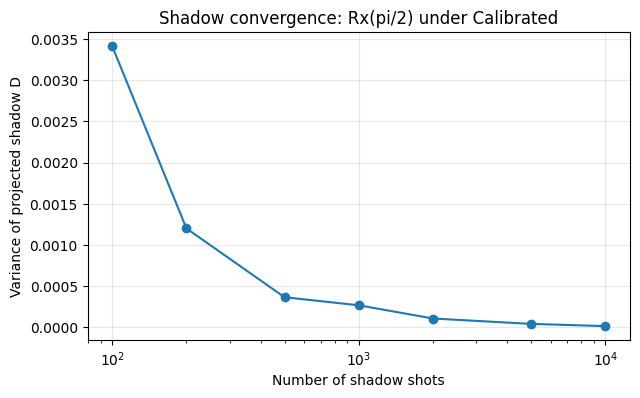

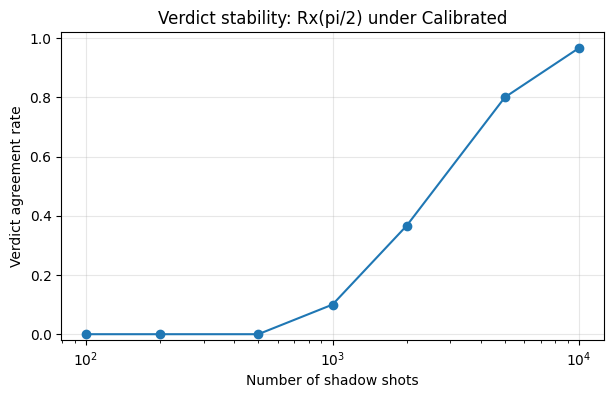

   shots  K_eff    D_mean     D_std     D_var  D_bias_abs  delta_log_mean  \
0    100      5  0.119091  0.058423  0.003413    0.118994        0.130584   
1    200     10  0.080168  0.034661  0.001201    0.080071        0.083631   
2    500     10  0.052838  0.019143  0.000366    0.052742        0.061599   
3   1000     10  0.035588  0.016386  0.000269    0.035492        0.037213   
4   2000     10  0.023212  0.010404  0.000108    0.023115        0.028131   
5   5000     10  0.014911  0.006562  0.000043    0.014815        0.019352   
6  10000     10  0.011463  0.003985  0.000016    0.011366        0.015729   

   delta_inc_mean  verdict_match_rate   exact_D exact_verdict  
0        0.102898            0.000000  0.000096          PASS  
1        0.073014            0.000000  0.000096          PASS  
2        0.048632            0.000000  0.000096          PASS  
3        0.033993            0.100000  0.000096          PASS  
4        0.022274            0.366667  0.000096          PASS  

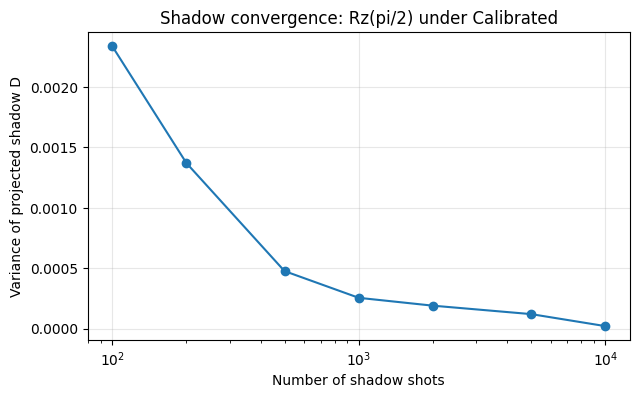

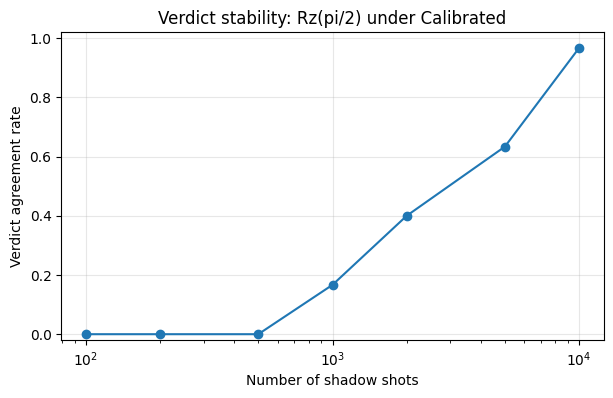

   shots  K_eff    D_mean     D_std     D_var  D_bias_abs  delta_log_mean  \
0    100      5  0.124472  0.048359  0.002339    0.124472        0.116757   
1    200     10  0.081369  0.037018  0.001370    0.081369        0.082522   
2    500     10  0.061201  0.021817  0.000476    0.061201        0.057319   
3   1000     10  0.035828  0.015960  0.000255    0.035828        0.037250   
4   2000     10  0.025190  0.013773  0.000190    0.025190        0.021642   
5   5000     10  0.018575  0.010950  0.000120    0.018575        0.018257   
6  10000     10  0.010766  0.004523  0.000020    0.010766        0.011687   

   delta_inc_mean  verdict_match_rate       exact_D exact_verdict  
0        0.111395            0.000000  2.220446e-16          PASS  
1        0.073376            0.000000  2.220446e-16          PASS  
2        0.057740            0.000000  2.220446e-16          PASS  
3        0.034200            0.166667  2.220446e-16          PASS  
4        0.024655            0.400000  2.22

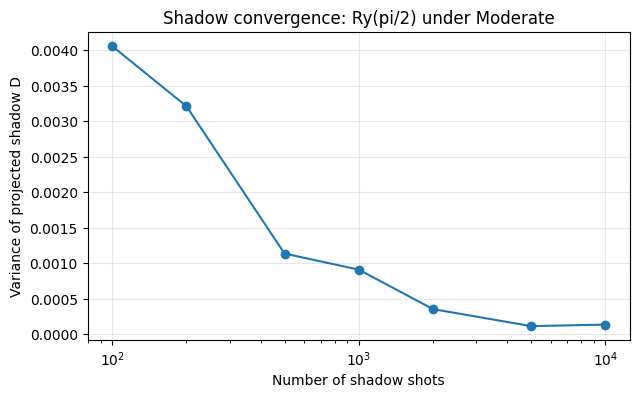

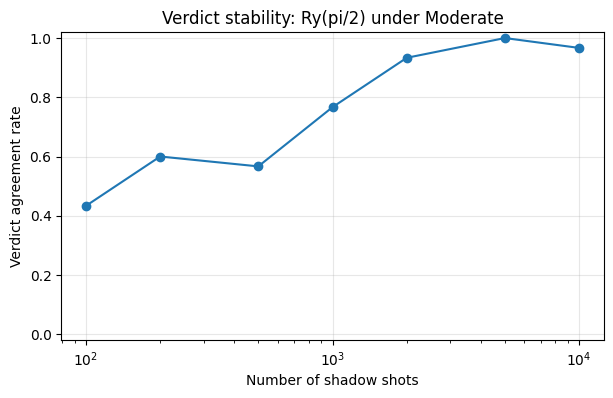

   shots  K_eff    D_mean     D_std     D_var  D_bias_abs  delta_log_mean  \
0    100      5  0.308958  0.063725  0.004061    0.040284        0.238997   
1    200     10  0.285100  0.056694  0.003214    0.016425        0.157895   
2    500     10  0.290576  0.033749  0.001139    0.021901        0.140492   
3   1000     10  0.277147  0.030205  0.000912    0.008473        0.132064   
4   2000     10  0.273147  0.018886  0.000357    0.004473        0.117273   
5   5000     10  0.276361  0.010817  0.000117    0.007686        0.112035   
6  10000     10  0.272539  0.011768  0.000138    0.003865        0.107594   

   delta_inc_mean  verdict_match_rate   exact_D exact_verdict  
0        0.269749            0.433333  0.268674     SOFT FAIL  
1        0.266120            0.600000  0.268674     SOFT FAIL  
2        0.276725            0.566667  0.268674     SOFT FAIL  
3        0.265112            0.766667  0.268674     SOFT FAIL  
4        0.263265            0.933333  0.268674     SOFT FAIL  

In [42]:
# ============================================================
# Shadow convergence study with variance and verdict stability
# ============================================================

def choose_mom_K(n_shots, K_max=10, min_block=20):
    """
    Keeping median-of-means blocks reasonably populated.
    """
    K_eff = max(1, min(K_max, n_shots // min_block))
    return K_eff

def shadow_convergence_study(
    gate_spec,
    regime,
    shot_list=(100, 200, 500, 1000, 2000, 5000, 10000),
    n_trials=25,
    nsteps=50
):
    exact = analyze_1q_gate_regime_exact(gate_spec, regime["params"], nsteps=nsteps)
    exact_verdict = exact["verdict"]
    exact_D = exact["D"]

    rows = []

    for N in shot_list:
        K_eff = choose_mom_K(N, K_max=10, min_block=20)

        D_vals = []
        dlog_vals = []
        dinc_vals = []
        verdicts = []

        for trial in range(n_trials):
            res = analyze_1q_gate_regime_shadow(
                gate_spec,
                regime["params"],
                n_shots=N,
                K=K_eff,
                seed=10000 + 100 * trial + N,
                nsteps=nsteps
            )
            D_vals.append(res["D"])
            dlog_vals.append(res["delta_log"])
            dinc_vals.append(res["delta_inc"])
            verdicts.append(res["verdict"])

        D_vals = np.array(D_vals, dtype=float)
        dlog_vals = np.array(dlog_vals, dtype=float)
        dinc_vals = np.array(dinc_vals, dtype=float)

        rows.append({
            "shots": N,
            "K_eff": K_eff,
            "D_mean": float(np.mean(D_vals)),
            "D_std": float(np.std(D_vals, ddof=1)) if len(D_vals) > 1 else 0.0,
            "D_var": float(np.var(D_vals, ddof=1)) if len(D_vals) > 1 else 0.0,
            "D_bias_abs": float(abs(np.mean(D_vals) - exact_D)),
            "delta_log_mean": float(np.mean(dlog_vals)),
            "delta_inc_mean": float(np.mean(dinc_vals)),
            "verdict_match_rate": float(np.mean([v == exact_verdict for v in verdicts])),
            "exact_D": exact_D,
            "exact_verdict": exact_verdict
        })

    df = pd.DataFrame(rows)

    plt.figure(figsize=(7, 4))
    plt.plot(df["shots"], df["D_var"], marker="o")
    plt.xscale("log")
    plt.xlabel("Number of shadow shots")
    plt.ylabel("Variance of projected shadow D")
    plt.title(f"Shadow convergence: {gate_spec['label']} under {regime['name']}")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(df["shots"], df["verdict_match_rate"], marker="o")
    plt.xscale("log")
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Number of shadow shots")
    plt.ylabel("Verdict agreement rate")
    plt.title(f"Verdict stability: {gate_spec['label']} under {regime['name']}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return df

df_conv_rx_cal = shadow_convergence_study(GATE_SPECS["Rx_pi_2"], REGIMES[0], n_trials=30)
print(df_conv_rx_cal)
print()

df_conv_rz_cal = shadow_convergence_study(GATE_SPECS["Rz_pi_2"], REGIMES[0], n_trials=30)
print(df_conv_rz_cal)
print()

df_conv_ry_mod = shadow_convergence_study(GATE_SPECS["Ry_pi_2"], REGIMES[1], n_trials=30)
print(df_conv_ry_mod)

In [49]:
%pip install --quiet mqt.bench &> /dev/null
from collections import OrderedDict, Counter

In [50]:
# -----------------------------
# 1. Load MQT-bench
# -----------------------------
from mqt.bench import BenchmarkLevel, get_benchmark

# Get a benchmark circuit on algorithmic level representing the GHZ state with 5 qubits
qc_algorithmic_level = get_benchmark(
    benchmark="ghz", level=BenchmarkLevel.ALG, circuit_size=5
)

# Draw the circuit
print(qc_algorithmic_level.draw())

                            ┌───┐ ░ ┌─┐            
   q_0: ────────────────────┤ X ├─░─┤M├────────────
                       ┌───┐└─┬─┘ ░ └╥┘┌─┐         
   q_1: ───────────────┤ X ├──■───░──╫─┤M├─────────
                  ┌───┐└─┬─┘      ░  ║ └╥┘┌─┐      
   q_2: ──────────┤ X ├──■────────░──╫──╫─┤M├──────
             ┌───┐└─┬─┘           ░  ║  ║ └╥┘┌─┐   
   q_3: ─────┤ X ├──■─────────────░──╫──╫──╫─┤M├───
        ┌───┐└─┬─┘                ░  ║  ║  ║ └╥┘┌─┐
   q_4: ┤ H ├──■──────────────────░──╫──╫──╫──╫─┤M├
        └───┘                     ░  ║  ║  ║  ║ └╥┘
meas: 5/═════════════════════════════╩══╩══╩══╩══╩═
                                     0  1  2  3  4 
